## 1. Import Libraries và Configuration

In [1]:
import pandas as pd
import numpy as np
import psycopg2
from psycopg2.extras import execute_values
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Cấu hình visualization
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

In [2]:
# Configuration
CSV_PATH = "F:/HK251/data_warehouse/WA_Fn-UseC_-HR-Employee-Attrition.csv"
DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "hr_data_warehouse"
DB_USER = "postgres"
DB_PASSWORD = "250904"

# ETL Batch ID
ETL_BATCH_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
print(f"ETL Batch ID: {ETL_BATCH_ID}")

ETL Batch ID: 20251210_104918


## 2. EXTRACT - Đọc dữ liệu từ CSV

In [3]:
# Đọc dữ liệu
df = pd.read_csv(CSV_PATH)
print(f"✅ Đọc thành công {len(df)} records từ CSV")
print(f"\n📊 Shape: {df.shape}")
print(f"📊 Columns: {df.shape[1]} columns")

✅ Đọc thành công 1470 records từ CSV

📊 Shape: (1470, 35)
📊 Columns: 35 columns


In [4]:
# Xem thông tin tổng quan
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [5]:
# Xem một số dòng đầu tiên
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## 3. TRANSFORM - Data Quality & Cleaning

### 3.1. Xóa các cột không có ý nghĩa phân tích

In [6]:
# Kiểm tra các cột chỉ có 1 giá trị duy nhất
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
print(f"Các cột có giá trị không đổi: {constant_cols}")

# Xóa các cột không có ý nghĩa
df_clean = df.drop(["EmployeeCount", "Over18", "StandardHours"], axis=1)
print(f"\n✅ Đã xóa {len(constant_cols)} cột không có ý nghĩa")
print(f"📊 Shape sau khi xóa: {df_clean.shape}")

Các cột có giá trị không đổi: ['EmployeeCount', 'Over18', 'StandardHours']

✅ Đã xóa 3 cột không có ý nghĩa
📊 Shape sau khi xóa: (1470, 32)


### 3.2. Kiểm tra Missing Values

In [7]:
# Kiểm tra missing values
null_counts = df_clean.isnull().sum()
print(f"Total missing values: {null_counts.sum()}")

if null_counts.sum() > 0:
    null_df = pd.DataFrame({
        'Column': null_counts.index,
        'Missing Count': null_counts.values,
        'Percentage': (null_counts.values / len(df_clean) * 100).round(2)
    })
    print(null_df[null_df['Missing Count'] > 0])
else:
    print("\n✅ Không có missing values trong dataset!")

Total missing values: 0

✅ Không có missing values trong dataset!


### 3.3. Data Type Validation & Conversion

In [8]:
# Chuyển đổi data types
df_clean = df_clean.copy()
df_clean['Age'] = df_clean['Age'].astype(int)
df_clean['MonthlyIncome'] = df_clean['MonthlyIncome'].astype(float)
df_clean['EmployeeNumber'] = df_clean['EmployeeNumber'].astype(int)

print("✅ Đã chuyển đổi data types")
print("\nData types chính:")
print(df_clean[['Age', 'MonthlyIncome', 'EmployeeNumber']].dtypes)

✅ Đã chuyển đổi data types

Data types chính:
Age                 int64
MonthlyIncome     float64
EmployeeNumber      int64
dtype: object


### 3.4. Feature Engineering - Tạo Attrition Label

In [9]:
# Tạo Attrition Label (0/1)
df_clean['Attrition_Label'] = (df_clean['Attrition'] == 'Yes').astype(int)

print("Attrition Distribution:")
print(df_clean['Attrition'].value_counts())
print(f"\nAttrition Rate: {df_clean['Attrition_Label'].mean() * 100:.2f}%")

Attrition Distribution:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Rate: 16.12%


### 3.5. Chuẩn hóa tên cột theo snake_case

In [10]:
# Chuẩn hóa tên cột
column_mapping = {
    'EmployeeNumber': 'employee_number',
    'Age': 'age',
    'Gender': 'gender',
    'MaritalStatus': 'marital_status',
    'Education': 'education',
    'EducationField': 'education_field',
    'DistanceFromHome': 'distance_from_home',
    'NumCompaniesWorked': 'num_companies_worked',
    'TotalWorkingYears': 'total_working_years',
    'JobRole': 'job_role',
    'JobLevel': 'job_level',
    'JobInvolvement': 'job_involvement',
    'Department': 'department',
    'Attrition': 'attrition',
    'Attrition_Label': 'attrition_label',
    'MonthlyIncome': 'monthly_income',
    'HourlyRate': 'hourly_rate',
    'DailyRate': 'daily_rate',
    'MonthlyRate': 'monthly_rate',
    'PercentSalaryHike': 'percent_salary_hike',
    'PerformanceRating': 'performance_rating',
    'EnvironmentSatisfaction': 'environment_satisfaction',
    'JobSatisfaction': 'job_satisfaction',
    'RelationshipSatisfaction': 'relationship_satisfaction',
    'WorkLifeBalance': 'work_life_balance',
    'YearsAtCompany': 'years_at_company',
    'YearsInCurrentRole': 'years_in_current_role',
    'YearsSinceLastPromotion': 'years_since_last_promotion',
    'YearsWithCurrManager': 'years_with_curr_manager',
    'BusinessTravel': 'business_travel',
    'OverTime': 'over_time',
    'StockOptionLevel': 'stock_option_level',
    'TrainingTimesLastYear': 'training_times_last_year'
}

df_clean = df_clean.rename(columns=column_mapping)
print(f"✅ Đã chuẩn hóa tên {len(column_mapping)} cột")

✅ Đã chuẩn hóa tên 33 cột


## 4. Phân tích và Trực quan hóa sau Tiền xử lý

### 4.1. Thống kê mô tả

In [11]:
# Thống kê mô tả cho các biến số
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
df_clean[numeric_cols].describe().round(2)

,age,daily_rate,distance_from_home,education,employee_number,environment_satisfaction,hourly_rate,job_involvement,job_level,job_satisfaction,...,relationship_satisfaction,stock_option_level,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_curr_manager,attrition_label
count,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,...,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00
mean,36.92,802.49,9.19,2.91,1024.87,2.72,65.89,2.73,2.06,2.73,...,2.71,0.79,11.28,2.80,2.76,7.01,4.23,2.19,4.12,0.16
std,9.14,403.51,8.11,1.02,602.02,1.09,20.33,0.71,1.11,1.10,...,1.08,0.85,7.78,1.29,0.71,6.13,3.62,3.22,3.57,0.37
min,18.00,102.00,1.00,1.00,1.00,1.00,30.00,1.00,1.00,1.00,...,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00
25%,30.00,465.00,2.00,2.00,491.25,2.00,48.00,2.00,1.00,2.00,...,2.00,0.00,6.00,2.00,2.00,3.00,2.00,0.00,2.00,0.00
50%,36.00,802.00,7.00,3.00,1020.50,3.00,66.00,3.00,2.00,3.00,...,3.00,1.00,10.00,3.00,3.00,5.00,3.00,1.00,3.00,0.00
75%,43.00,1157.00,14.00,4.00,1555.75,4.00,83.75,3.00,3.00,4.00,...,4.00,1.00,15.00,3.00,3.00,9.00,7.00,3.00,7.00,0.00
max,60.00,1499.00,29.00,5.00,2068.00,4.00,100.00,4.00,5.00,4.00,...,4.00,3.00,40.00,6.00,4.00,40.00,18.00,15.00,17.00,1.00


### 4.2. Phân bố Attrition

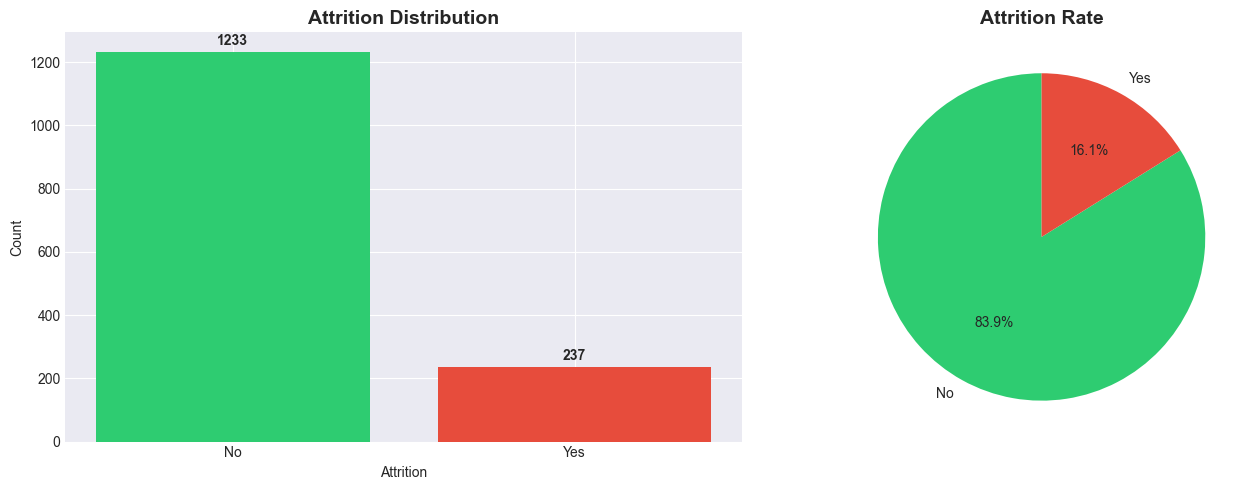


📊 Attrition Summary:
  - No Attrition: 1233 (83.9%)
  - Attrition: 237 (16.1%)


In [12]:
# Visualization: Attrition Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
attrition_counts = df_clean['attrition'].value_counts()
axes[0].bar(attrition_counts.index, attrition_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Attrition Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Attrition')
axes[0].set_ylabel('Count')
for i, v in enumerate(attrition_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(attrition_counts.values, labels=attrition_counts.index, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Attrition Rate', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n📊 Attrition Summary:")
print(f"  - No Attrition: {attrition_counts['No']} ({attrition_counts['No']/len(df_clean)*100:.1f}%)")
print(f"  - Attrition: {attrition_counts['Yes']} ({attrition_counts['Yes']/len(df_clean)*100:.1f}%)")

### 4.3. Phân tích Attrition theo Department

📊 Attrition by Department:
attrition                No  Yes  Total  Attrition_Rate
department                                             
Human Resources          51   12     63           19.05
Research & Development  828  133    961           13.84
Sales                   354   92    446           20.63


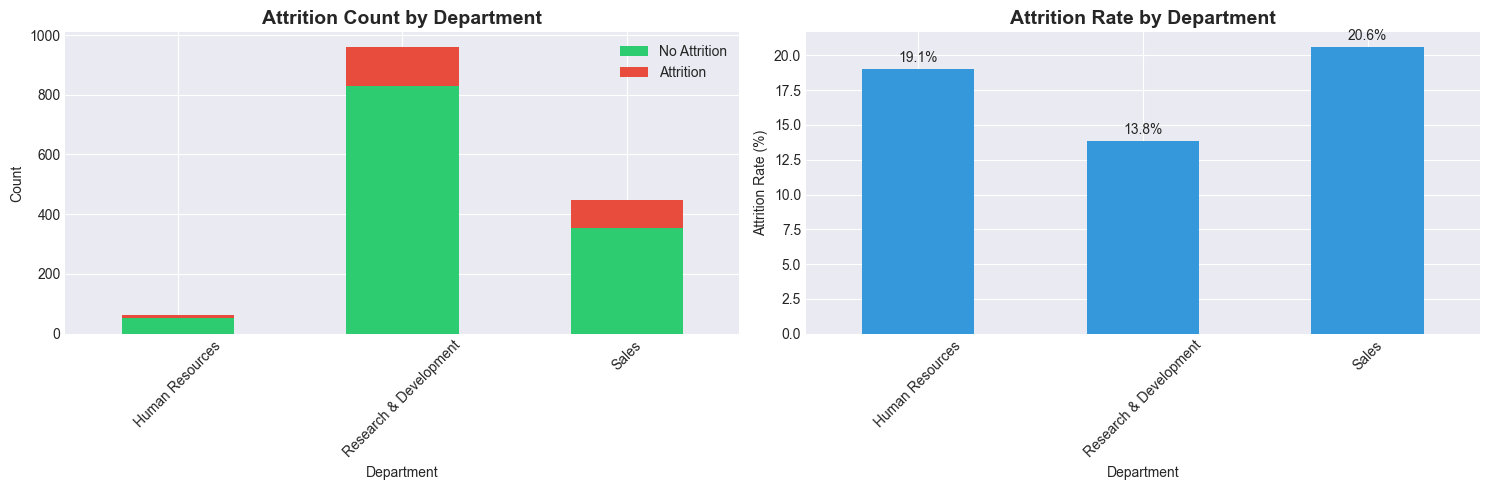

In [13]:
# Attrition by Department
dept_attrition = df_clean.groupby(['department', 'attrition']).size().unstack(fill_value=0)
dept_attrition['Total'] = dept_attrition.sum(axis=1)
dept_attrition['Attrition_Rate'] = (dept_attrition['Yes'] / dept_attrition['Total'] * 100).round(2)

print("📊 Attrition by Department:")
print(dept_attrition)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Stacked bar chart
dept_attrition[['No', 'Yes']].plot(kind='bar', stacked=True, ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Attrition Count by Department', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Department')
axes[0].set_ylabel('Count')
axes[0].legend(['No Attrition', 'Attrition'])
axes[0].tick_params(axis='x', rotation=45)

# Attrition rate
dept_attrition['Attrition_Rate'].plot(kind='bar', ax=axes[1], color='#3498db')
axes[1].set_title('Attrition Rate by Department', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Department')
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(dept_attrition['Attrition_Rate'].values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center')

plt.tight_layout()
plt.show()

### 4.4. Phân tích Attrition theo Job Role

📊 Attrition by Job Role:
attrition                   No  Yes  Total  Attrition_Rate
job_role                                                  
Sales Representative        50   33     83           39.76
Laboratory Technician      197   62    259           23.94
Human Resources             40   12     52           23.08
Sales Executive            269   57    326           17.48
Research Scientist         245   47    292           16.10
Manufacturing Director     135   10    145            6.90
Healthcare Representative  122    9    131            6.87
Manager                     97    5    102            4.90
Research Director           78    2     80            2.50


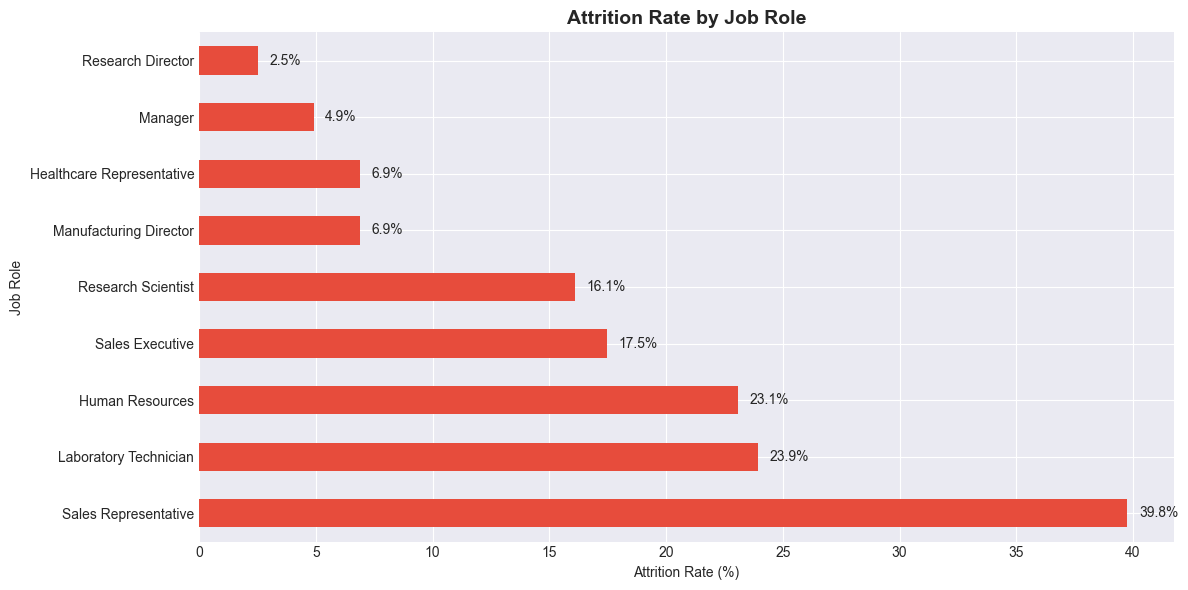

In [14]:
# Attrition by Job Role
role_attrition = df_clean.groupby(['job_role', 'attrition']).size().unstack(fill_value=0)
role_attrition['Total'] = role_attrition.sum(axis=1)
role_attrition['Attrition_Rate'] = (role_attrition['Yes'] / role_attrition['Total'] * 100).round(2)
role_attrition = role_attrition.sort_values('Attrition_Rate', ascending=False)

print("📊 Attrition by Job Role:")
print(role_attrition)

# Visualization
plt.figure(figsize=(12, 6))
role_attrition['Attrition_Rate'].plot(kind='barh', color='#e74c3c')
plt.title('Attrition Rate by Job Role', fontsize=14, fontweight='bold')
plt.xlabel('Attrition Rate (%)')
plt.ylabel('Job Role')
for i, v in enumerate(role_attrition['Attrition_Rate'].values):
    plt.text(v + 0.5, i, f'{v:.1f}%', va='center')
plt.tight_layout()
plt.show()

### 4.5. Phân tích Demographics

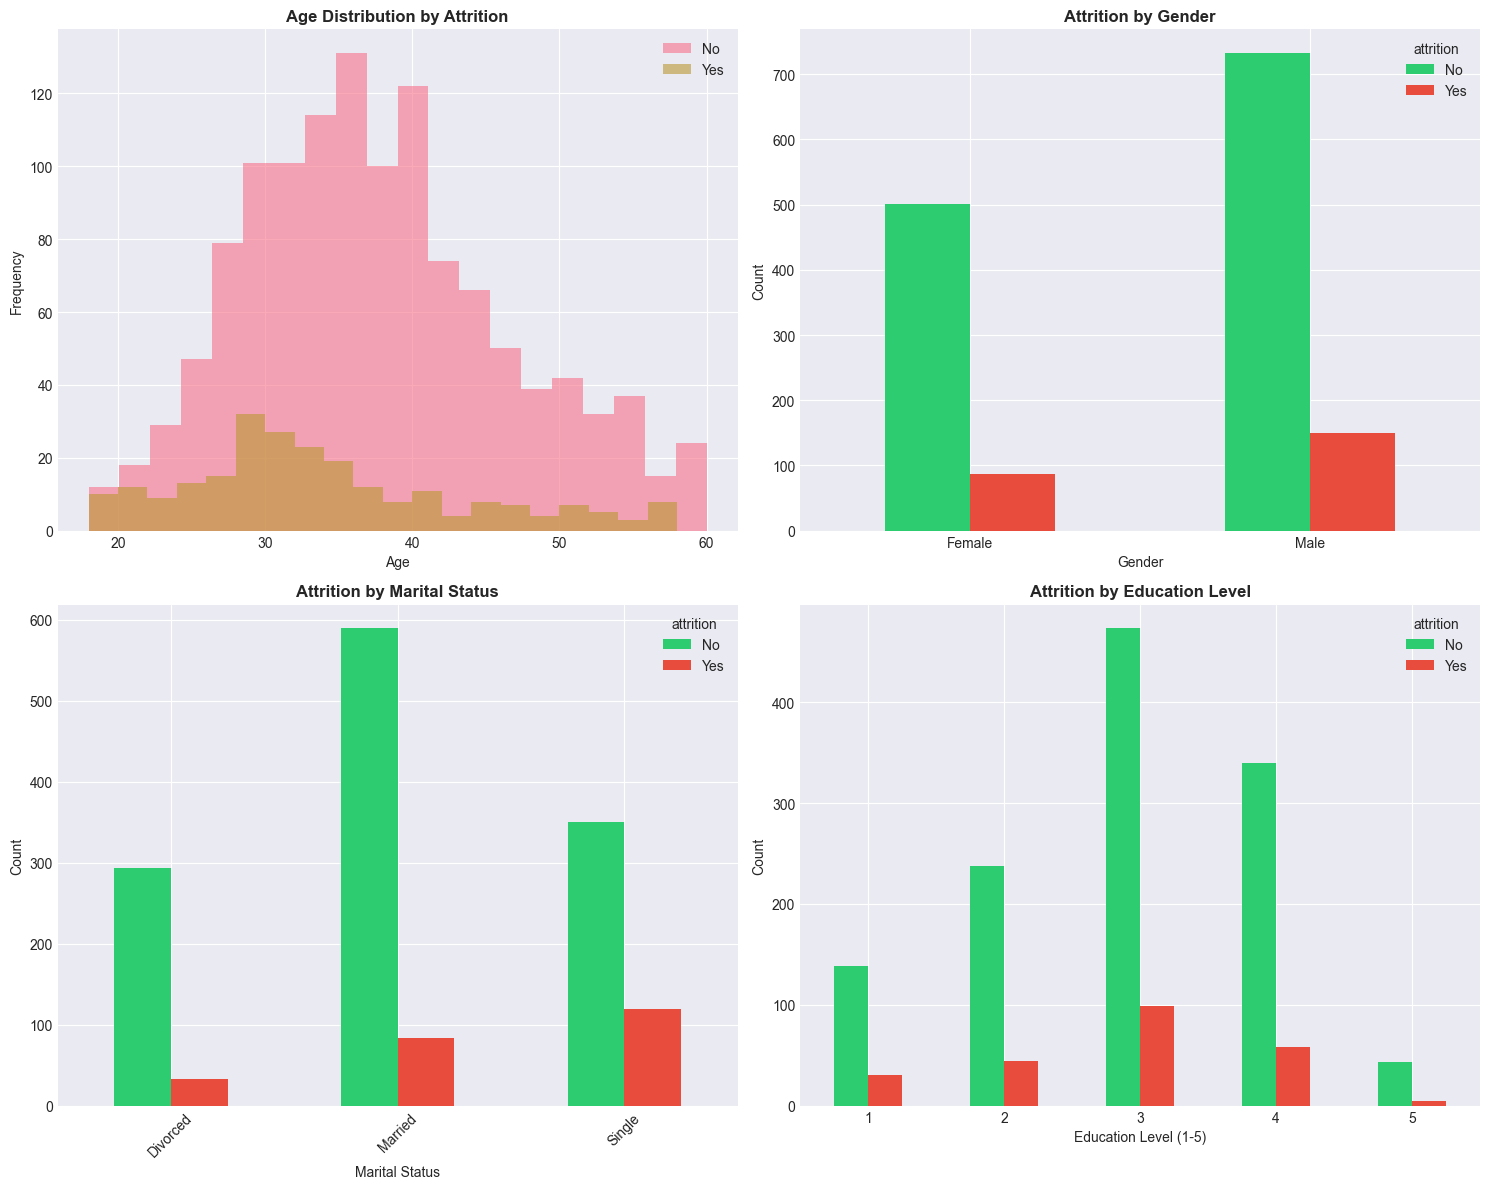

In [15]:
# Demographics Analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Age Distribution
df_clean.groupby(['attrition'])['age'].hist(bins=20, alpha=0.6, ax=axes[0, 0], legend=True)
axes[0, 0].set_title('Age Distribution by Attrition', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend(['No', 'Yes'])

# Gender
gender_attrition = pd.crosstab(df_clean['gender'], df_clean['attrition'])
gender_attrition.plot(kind='bar', ax=axes[0, 1], color=['#2ecc71', '#e74c3c'])
axes[0, 1].set_title('Attrition by Gender', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Gender')
axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', rotation=0)

# Marital Status
marital_attrition = pd.crosstab(df_clean['marital_status'], df_clean['attrition'])
marital_attrition.plot(kind='bar', ax=axes[1, 0], color=['#2ecc71', '#e74c3c'])
axes[1, 0].set_title('Attrition by Marital Status', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Marital Status')
axes[1, 0].set_ylabel('Count')
axes[1, 0].tick_params(axis='x', rotation=45)

# Education Level
edu_attrition = pd.crosstab(df_clean['education'], df_clean['attrition'])
edu_attrition.plot(kind='bar', ax=axes[1, 1], color=['#2ecc71', '#e74c3c'])
axes[1, 1].set_title('Attrition by Education Level', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Education Level (1-5)')
axes[1, 1].set_ylabel('Count')
axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### 4.6. Phân tích Compensation và Satisfaction

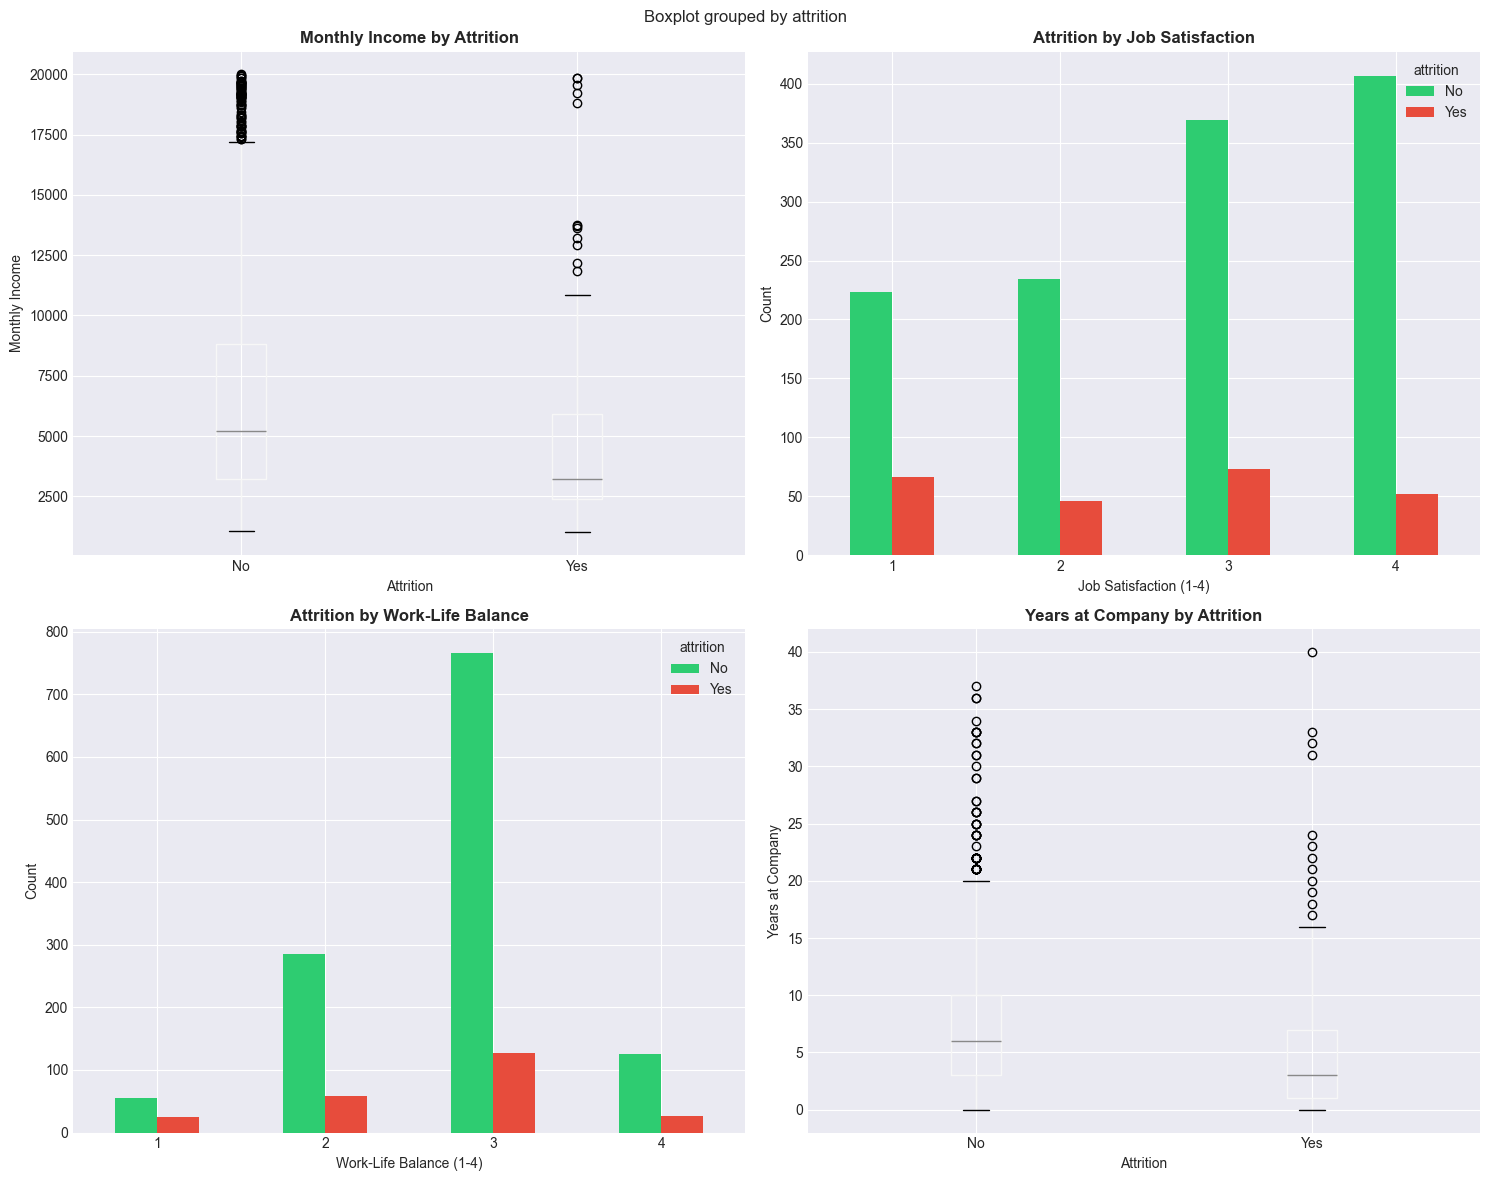

In [16]:
# Compensation and Satisfaction Analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Monthly Income by Attrition
df_clean.boxplot(column='monthly_income', by='attrition', ax=axes[0, 0])
axes[0, 0].set_title('Monthly Income by Attrition', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Attrition')
axes[0, 0].set_ylabel('Monthly Income')
plt.sca(axes[0, 0])
plt.xticks([1, 2], ['No', 'Yes'])

# Job Satisfaction
satisfaction_attrition = pd.crosstab(df_clean['job_satisfaction'], df_clean['attrition'])
satisfaction_attrition.plot(kind='bar', ax=axes[0, 1], color=['#2ecc71', '#e74c3c'])
axes[0, 1].set_title('Attrition by Job Satisfaction', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Job Satisfaction (1-4)')
axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', rotation=0)

# Work Life Balance
wlb_attrition = pd.crosstab(df_clean['work_life_balance'], df_clean['attrition'])
wlb_attrition.plot(kind='bar', ax=axes[1, 0], color=['#2ecc71', '#e74c3c'])
axes[1, 0].set_title('Attrition by Work-Life Balance', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Work-Life Balance (1-4)')
axes[1, 0].set_ylabel('Count')
axes[1, 0].tick_params(axis='x', rotation=0)

# Years at Company
df_clean.boxplot(column='years_at_company', by='attrition', ax=axes[1, 1])
axes[1, 1].set_title('Years at Company by Attrition', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Attrition')
axes[1, 1].set_ylabel('Years at Company')
plt.sca(axes[1, 1])
plt.xticks([1, 2], ['No', 'Yes'])

plt.tight_layout()
plt.show()

### 4.7. Correlation Analysis

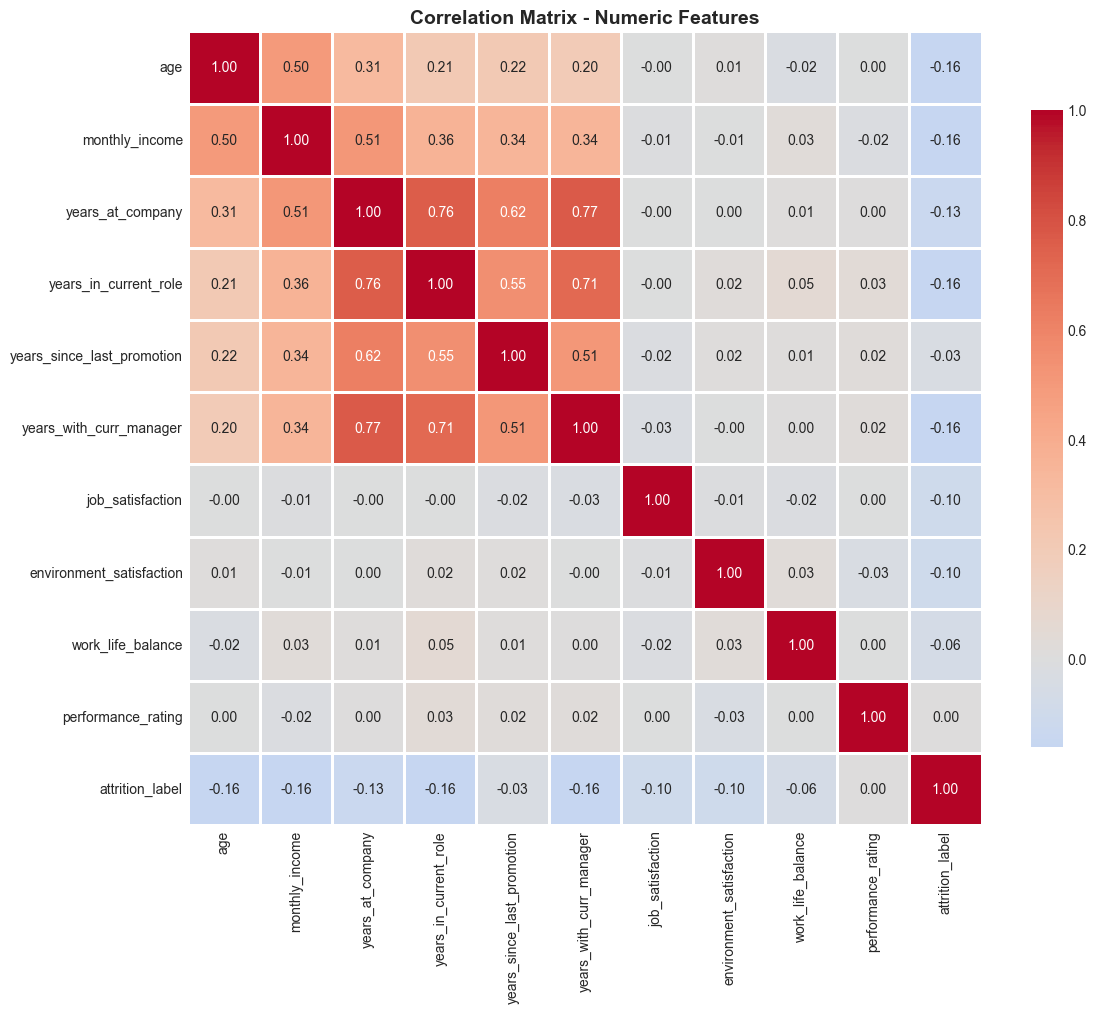


📊 Top 10 correlations with Attrition:
performance_rating            0.002889
years_since_last_promotion   -0.033019
work_life_balance            -0.063939
environment_satisfaction     -0.103369
job_satisfaction             -0.103481
years_at_company             -0.134392
years_with_curr_manager      -0.156199
age                          -0.159205
monthly_income               -0.159840
years_in_current_role        -0.160545
Name: attrition_label, dtype: float64


In [17]:
# Correlation with Attrition Label
numeric_features = ['age', 'monthly_income', 'years_at_company', 'years_in_current_role',
                    'years_since_last_promotion', 'years_with_curr_manager',
                    'job_satisfaction', 'environment_satisfaction', 'work_life_balance',
                    'performance_rating', 'attrition_label']

corr_matrix = df_clean[numeric_features].corr()

# Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Top correlations with attrition
print("\n📊 Top 10 correlations with Attrition:")
attrition_corr = corr_matrix['attrition_label'].sort_values(ascending=False)
print(attrition_corr[attrition_corr.index != 'attrition_label'].head(10))

### 4.8. Tổng hợp bảng thống kê sau tiền xử lý

In [18]:
# Summary Statistics Table
summary_stats = pd.DataFrame({
    'Metric': [
        'Total Records',
        'Total Features',
        'Attrition Count',
        'Attrition Rate (%)',
        'Unique Departments',
        'Unique Job Roles',
        'Avg Age',
        'Avg Monthly Income',
        'Avg Years at Company',
        'Missing Values'
    ],
    'Value': [
        len(df_clean),
        df_clean.shape[1],
        df_clean['attrition_label'].sum(),
        f"{df_clean['attrition_label'].mean() * 100:.2f}%",
        df_clean['department'].nunique(),
        df_clean['job_role'].nunique(),
        f"{df_clean['age'].mean():.1f}",
        f"${df_clean['monthly_income'].mean():,.2f}",
        f"{df_clean['years_at_company'].mean():.1f}",
        df_clean.isnull().sum().sum()
    ]
})

print("\n" + "="*60)
print("📊 SUMMARY STATISTICS - AFTER DATA PREPROCESSING")
print("="*60)
print(summary_stats.to_string(index=False))
print("="*60)


📊 SUMMARY STATISTICS - AFTER DATA PREPROCESSING
              Metric     Value
       Total Records      1470
      Total Features        33
     Attrition Count       237
  Attrition Rate (%)    16.12%
  Unique Departments         3
    Unique Job Roles         9
             Avg Age      36.9
  Avg Monthly Income $6,502.93
Avg Years at Company       7.0
      Missing Values         0


## 5. LOAD - Dimension Tables Creation

### 5.1. Database Connection Functions

In [19]:
def get_db_connection():
    """Create database connection"""
    return psycopg2.connect(
        host=DB_HOST,
        port=DB_PORT,
        database=DB_NAME,
        user=DB_USER,
        password=DB_PASSWORD
    )

# Test connection
try:
    conn = get_db_connection()
    print("✅ Database connection successful!")
    conn.close()
except Exception as e:
    print(f"❌ Database connection failed: {e}")

✅ Database connection successful!


### 5.2. Load Dimension Table Function

In [20]:
def load_dimension_table(df, table_name, columns, key_column=None):
    """Load dimension table with deduplication"""
    print(f"\nLoading {table_name}...")

    # Get distinct values
    if key_column:
        dim_df = df[columns].drop_duplicates(subset=[key_column])
    else:
        dim_df = df[columns].drop_duplicates()

    # Reset index and add surrogate key
    dim_df = dim_df.reset_index(drop=True)
    table_short = table_name.replace('dim_', '')
    key_name = f"{table_short}_key"
    dim_df[key_name] = range(1, len(dim_df) + 1)

    # Add timestamps
    dim_df['created_at'] = datetime.now()
    
    # Check if table has updated_at column
    conn = get_db_connection()
    has_updated_at = False
    try:
        with conn.cursor() as cur:
            cur.execute(f"""
                SELECT 1 FROM information_schema.columns 
                WHERE table_name = '{table_name}' AND column_name = 'updated_at'
            """)
            has_updated_at = cur.fetchone() is not None
    finally:
        conn.close()
    
    if has_updated_at:
        dim_df['updated_at'] = datetime.now()
        cols = [key_name] + columns + ['created_at', 'updated_at']
    else:
        cols = [key_name] + columns + ['created_at']
    
    dim_df = dim_df[cols]

    # Load to database
    conn = get_db_connection()
    try:
        with conn.cursor() as cur:
            cur.execute(f"TRUNCATE TABLE {table_name} CASCADE")
            columns_list = dim_df.columns.tolist()
            values = [tuple(row) for row in dim_df.astype(object).values]
            query = f"""
                INSERT INTO {table_name} ({', '.join(columns_list)})
                VALUES %s
            """
            execute_values(cur, query, values)
        conn.commit()
        print(f"✅ Loaded {len(dim_df)} records into {table_name}")
    except Exception as e:
        conn.rollback()
        print(f"❌ Error loading {table_name}: {e}")
        raise
    finally:
        conn.close()

    return dim_df

### 5.3. Load Dimensions

In [21]:
dim_dfs = {}

# DIM_EMPLOYEE
employee_cols = ['employee_number', 'age', 'gender', 'marital_status', 'education',
                'education_field', 'distance_from_home', 'num_companies_worked', 'total_working_years']
dim_employee = load_dimension_table(df_clean, 'dim_employee', employee_cols, 'employee_number')
dim_dfs['dim_employee'] = dim_employee

# DIM_JOB_ROLE
job_role_cols = ['job_role', 'job_level', 'job_involvement']
dim_job_role = load_dimension_table(df_clean, 'dim_job_role', job_role_cols, 'job_role')
dim_dfs['dim_job_role'] = dim_job_role

# DIM_DEPARTMENT
department_cols = ['department']
dim_department = load_dimension_table(df_clean, 'dim_department', department_cols, 'department')
dim_dfs['dim_department'] = dim_department


Loading dim_employee...
✅ Loaded 1470 records into dim_employee

Loading dim_job_role...
✅ Loaded 9 records into dim_job_role

Loading dim_department...
✅ Loaded 1470 records into dim_employee

Loading dim_job_role...
✅ Loaded 9 records into dim_job_role

Loading dim_department...
✅ Loaded 3 records into dim_department
✅ Loaded 3 records into dim_department


### 5.4. Load DIM_TIME

In [22]:
# DIM_TIME
time_df = pd.DataFrame({
    'time_key': [1],
    'load_date': [datetime.now().date()],
    'year': [datetime.now().year],
    'quarter': [((datetime.now().month - 1) // 3) + 1],
    'month': [datetime.now().month],
    'week': [datetime.now().isocalendar()[1]],
    'day': [datetime.now().day],
    'created_at': [datetime.now()]
})

conn = get_db_connection()
try:
    with conn.cursor() as cur:
        cur.execute("TRUNCATE TABLE dim_time CASCADE")
        execute_values(cur, """
            INSERT INTO dim_time (time_key, load_date, year, quarter, month, week, day, created_at)
            VALUES %s
        """, [tuple(time_df.astype(object).iloc[0])])
    conn.commit()
    print("\n✅ Loaded 1 record into dim_time")
finally:
    conn.close()

dim_dfs['dim_time'] = time_df


✅ Loaded 1 record into dim_time


## 6. LOAD - Fact Table Creation

In [23]:
def load_fact_table(df, dim_dfs):
    """Load fact table with foreign keys"""
    print("\nLoading fact_hr_attrition...")

    # Create mappings for foreign keys
    employee_map = dict(zip(dim_dfs['dim_employee']['employee_number'],
                           dim_dfs['dim_employee']['employee_key']))
    job_role_map = dict(zip(dim_dfs['dim_job_role']['job_role'],
                           dim_dfs['dim_job_role']['job_role_key']))
    department_map = dict(zip(dim_dfs['dim_department']['department'],
                             dim_dfs['dim_department']['department_key']))
    time_key = dim_dfs['dim_time']['time_key'].iloc[0]

    # Create fact records
    fact_records = []
    for _, row in df.iterrows():
        fact_record = (
            int(employee_map.get(row['employee_number'])),
            int(job_role_map.get(row['job_role'])),
            int(department_map.get(row['department'])),
            int(time_key),
            str(row['attrition']),
            int(row['attrition_label']),
            float(row['monthly_income']),
            float(row['hourly_rate']),
            float(row['daily_rate']),
            float(row['monthly_rate']),
            int(row['percent_salary_hike']),
            int(row['performance_rating']),
            int(row['environment_satisfaction']),
            int(row['job_satisfaction']),
            int(row['relationship_satisfaction']),
            int(row['work_life_balance']),
            int(row['years_at_company']),
            int(row['years_in_current_role']),
            int(row['years_since_last_promotion']),
            int(row['years_with_curr_manager']),
            str(row['business_travel']),
            str(row['over_time']),
            int(row['stock_option_level']),
            int(row['training_times_last_year']),
            datetime.now(),
            ETL_BATCH_ID
        )
        fact_records.append(fact_record)

    # Load to database
    conn = get_db_connection()
    try:
        with conn.cursor() as cur:
            cur.execute("TRUNCATE TABLE fact_hr_attrition CASCADE")
            query = """
                INSERT INTO fact_hr_attrition (
                    employee_key, job_role_key, department_key, time_key,
                    attrition, attrition_label, monthly_income, hourly_rate,
                    daily_rate, monthly_rate, percent_salary_hike,
                    performance_rating, environment_satisfaction, job_satisfaction,
                    relationship_satisfaction, work_life_balance,
                    years_at_company, years_in_current_role, years_since_last_promotion,
                    years_with_curr_manager, business_travel, over_time,
                    stock_option_level, training_times_last_year,
                    load_timestamp, etl_batch_id
                ) VALUES %s
            """
            execute_values(cur, query, fact_records)
        conn.commit()
        print(f"✅ Loaded {len(fact_records)} records into fact_hr_attrition")
    except Exception as e:
        conn.rollback()
        print(f"❌ Error loading fact_hr_attrition: {e}")
        raise
    finally:
        conn.close()

# Execute
load_fact_table(df_clean, dim_dfs)


Loading fact_hr_attrition...
✅ Loaded 1470 records into fact_hr_attrition
✅ Loaded 1470 records into fact_hr_attrition


## 7. ETL Summary

In [24]:
print("\n" + "="*60)
print("🎉 ETL PROCESS COMPLETED SUCCESSFULLY")
print("="*60)
print(f"Batch ID: {ETL_BATCH_ID}")
print(f"Total records processed: {len(df_clean)}")
print(f"\nDimension Tables:")
print(f"  - dim_employee: {len(dim_dfs['dim_employee'])} records")
print(f"  - dim_job_role: {len(dim_dfs['dim_job_role'])} records")
print(f"  - dim_department: {len(dim_dfs['dim_department'])} records")
print(f"  - dim_time: 1 record")
print(f"\nFact Table:")
print(f"  - fact_hr_attrition: {len(df_clean)} records")
print("="*60)
print("\n✅ Data Warehouse ready for Power BI and ML analysis!")


🎉 ETL PROCESS COMPLETED SUCCESSFULLY
Batch ID: 20251210_104918
Total records processed: 1470

Dimension Tables:
  - dim_employee: 1470 records
  - dim_job_role: 9 records
  - dim_department: 3 records
  - dim_time: 1 record

Fact Table:
  - fact_hr_attrition: 1470 records

✅ Data Warehouse ready for Power BI and ML analysis!


## 8. Verification - Query from Data Warehouse

In [25]:
# Verify data in warehouse
conn = get_db_connection()
try:
    # Check record counts
    query = """
    SELECT 'dim_employee' as table_name, COUNT(*) as record_count FROM dim_employee
    UNION ALL
    SELECT 'dim_job_role', COUNT(*) FROM dim_job_role
    UNION ALL
    SELECT 'dim_department', COUNT(*) FROM dim_department
    UNION ALL
    SELECT 'dim_time', COUNT(*) FROM dim_time
    UNION ALL
    SELECT 'fact_hr_attrition', COUNT(*) FROM fact_hr_attrition
    """
    verification_df = pd.read_sql(query, conn)
    print("\n📊 Data Warehouse Verification:")
    print(verification_df.to_string(index=False))
    
    # Sample data from view
    print("\n📊 Sample from vw_attrition_by_department:")
    view_df = pd.read_sql("SELECT * FROM vw_attrition_by_department", conn)
    print(view_df.to_string(index=False))
    
finally:
    conn.close()


📊 Data Warehouse Verification:
       table_name  record_count
     dim_employee          1470
     dim_job_role             9
   dim_department             3
         dim_time             1
fact_hr_attrition          1470

📊 Sample from vw_attrition_by_department:
            department  total_employees  attrition_count  attrition_rate_percent  avg_monthly_income  avg_job_satisfaction
       Human Resources               63               12                   19.05             6654.51                  2.60
Research & Development              961              133                   13.84             6281.25                  2.73
                 Sales              446               92                   20.63             6959.17                  2.75
